In [1]:
!ls

 CHEMBL612532.csv   CHEMBL614448.csv  'Dataset_Upload_&_Intial_Cleaning.ipynb'


In [4]:
import pandas as pd

# Load the CSV file
file_path = "CHEMBL614448.csv"

# Read the CSV file
df = pd.read_csv(file_path, sep=";")
df.columns = df.columns.str.replace('"', '').str.strip() 

# Check the total number of dataset
print(f"Total dataset imported: \n{len(df)}")

# Check the first few rows
print("First few rows of the dataset:")
print(df.head())

# Check the column names
print("Columns in CSV:", df.columns)

df.to_excel("Initial_Dataset.xlsx")


Total dataset imported: 
2569
First few rows of the dataset:
  Molecule ChEMBL ID          Molecule Name  Molecule Max Phase  \
0         CHEMBL1730             CEFOTAXIME                 4.0   
1         CHEMBL1433  DOXYCYCLINE ANHYDROUS                 4.0   
2      CHEMBL3249232                    NaN                 NaN   
3      CHEMBL3249267                    NaN                 NaN   
4      CHEMBL2040927                    NaN                 NaN   

   Molecular Weight  #RO5 Violations  AlogP Compound Key  \
0            455.47              1.0  -0.62   Cefotaxime   
1            444.44              1.0  -0.35  SID90340791   
2            621.95              2.0   5.52           13   
3            693.35              2.0   8.83           49   
4            504.42              2.0   6.30           5e   

                                              Smiles Standard Type  \
0  CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(COC(C)...           MIC   
1  C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C

In [6]:
# Check the column names
print("\nColumns in dataset:")
print(df.columns)

# Check the unique values in 'Standard Type' column
print("\nUnique values in 'Standard Type':")
print(df["Standard Type"].unique())

# Check what values are present in 'Standard Units'
print("\nUnique values in 'Standard Units':")
print(df["Standard Units"].unique())
print(df["Standard Units"].value_counts())


Columns in dataset:
Index(['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase',
       'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key',
       'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value',
       'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment',
       'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE',
       'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate',
       'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID',
       'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID',
       'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction',
       'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation',
       'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type',
       'Document ChEMBL ID', 'Source ID', 'Source Description',
       'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties',
       'Action Type', 'Sta

In [8]:
import numpy as np
import pandas as pd
import re

# Ensure column names are correct
mic_col = "Standard Value"  # MIC value column
units_col = "Standard Units"  # Unit of measurement column
mw_col = "Molecular Weight"  # Molecular weight column

# Convert MIC and MW to numeric
df[mic_col] = pd.to_numeric(df[mic_col], errors="coerce")
df[mw_col] = pd.to_numeric(df[mw_col], errors="coerce")

# Drop rows with missing MIC or MW values
df = df.dropna(subset=[mic_col, mw_col])

# Function to convert MIC values to µM
def convert_mic(value, unit, molecular_weight):
    if pd.isnull(unit) or unit.strip().lower() == "nan":
        return None

    unit = str(unit).strip().replace("'", "^").replace(" ", "").lower()

    try:
        # Handle embedded scientific notation
        if re.match(r'10\^[-+]?\d+um', unit):
            power = int(re.search(r'10\^([-+]?\d+)', unit).group(1))
            return value * (10 ** power)

        if re.match(r'10\^[-+]?\d+nm', unit):
            power = int(re.search(r'10\^([-+]?\d+)', unit).group(1))
            return value * (10 ** power) / 1000

        if re.match(r'10\^[-+]?\d+.*', unit):
            power = int(re.search(r'10\^([-+]?\d+)', unit).group(1))
            return value * (10 ** power)

        # Direct conversions
        if unit == "nm":
            return value / 1000
        if unit == "mm":
            return value * 1000
        if unit in ["10^-3mm", "10^-3mM"]:
            return value
        if unit == "10^2umol/ml":
            return value * 100

        # Mass-based units
        if unit in ["ug.ml-1", "ug/mL", "ugml", "ug l-1", "ug cm**-3", "microg/cm3", "ug m1 l-1"]:
            return (value / molecular_weight) * 1000
        if unit in ["ug mg-1", "ug"]:
            return (value / molecular_weight) * 1000
        if unit in ["ug/g"]:
            return (value / molecular_weight) * 1000
        if unit in ["pmol/l"]:
            return value / 1000

        # Percent solutions – approximate
        if unit == "%":
            return (value * 10 * 1e6) / molecular_weight  # assuming 1% = 10 g/L

        # ppm
        if unit in ["ppm", "p.p.m."]:
            return (value / molecular_weight) * 1000

        # Special cases
        if unit in ["10^-3micromol/ml", "10'-3micromol/ml", "10'-3um/ml", "10'-3umol/ml"]:
            return value * 0.001
        if unit in ["10'-2umol/ml", "10'-2mmol/ml", "10'-2micromol/ml", "10'-2umol"]:
            return value * 10

        # Non-convertible units
        if unit in [
            "microg", "ug", "uL/ml", "ug/disk", "ug disk-1",
            "iu/ml", "u ml-1", "ucm/s", "ug cm**-2", "ug/sq.cm"
        ]:
            return None

        # Unknown unit
        print(f"Unknown unit: {unit}, value: {value}")
        return None
    except Exception as e:
        print(f"Error converting unit {unit} with value {value}: {e}")
        return None

# Apply conversion
df["MIC_µM"] = df.apply(lambda row: convert_mic(row[mic_col], row[units_col], row[mw_col]), axis=1)

# Drop rows where conversion failed
df = df.dropna(subset=["MIC_µM"])

print(f"Remaining records after unit conversion: {len(df)}")
df.head()


Remaining records after unit conversion: 2457


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value,MIC_µM
0,CHEMBL1730,CEFOTAXIME,4.0,455.47,1.0,-0.62,Cefotaxime,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(COC(C)...,MIC,'>',...,1,Scientific Literature,Antimicrob Agents Chemother,2010,NaN,NaN,NaN,NaN,128.0,281.028388
1,CHEMBL1433,DOXYCYCLINE ANHYDROUS,4.0,444.44,1.0,-0.35,SID90340791,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,MIC,'=',...,1,Scientific Literature,Antimicrob Agents Chemother,2009,NaN,NaN,NaN,NaN,0.5,1.125011
2,CHEMBL3249232,NaN,NaN,621.95,2.0,5.52,13,C[N+](C)(CCCOc1c(Br)cc(Br)cc1Br)Cc1ccc([N+](=O...,MIC,'>',...,1,Scientific Literature,J Med Chem,1977,NaN,NaN,NaN,NaN,200.0,321.569258
3,CHEMBL3249267,NaN,NaN,693.35,2.0,8.83,49,Cc1cc(OCCCCCCCCCCCC[N+](C)(C)Cc2ccc([N+](=O)[O...,MIC,'>',...,1,Scientific Literature,J Med Chem,1977,NaN,NaN,NaN,NaN,200.0,288.454604
4,CHEMBL2040927,NaN,NaN,504.42,2.0,6.30,5e,CC1(C)CC(=O)C2=C(C1)N(Nc1ccc(Cl)cc1)C(N)=C(C#N...,MIC,'=',...,1,Scientific Literature,Eur J Med Chem,2012,NaN,NaN,NaN,NaN,500.0,991.237461


In [9]:
# Check if columns exist
if "Standard Relation" not in df.columns or "MIC_µM" not in df.columns:
    raise KeyError("Columns 'Standard Relation' or 'MIC_µM' are missing from the DataFrame.")

# Ensure MIC_µM is numeric
df["MIC_µM"] = pd.to_numeric(df["MIC_µM"], errors="coerce")

# Check unique values in "Standard Relation"
df["Standard Relation"] = df["Standard Relation"].astype(str).str.strip().str.replace("'", "")
print("Cleaned Unique Standard Relation values:", df["Standard Relation"].unique())

def classify_activity(row):
    """
    Classifies compounds as 'Active' or 'Inactive' based on MIC_µM and Standard Relation.
    """
    mic_value = row["MIC_µM"]
    relation = row["Standard Relation"]
    
    # Skip missing values
    if pd.isnull(mic_value) or pd.isnull(relation):
        return np.nan  

    relation = relation.strip()  # Remove spaces
    relation = relation.replace("'", "")  # Remove extra quotes

    # Define classification based on relation type
    if relation in ["=", "<", "<="]:  # MIC is below or equal to cutoff
        return "Active" if mic_value < 10 else "Inactive"
    elif relation == ">":  # MIC is explicitly greater
        return "Inactive"
    elif relation == ">=":  # MIC is at least 10, consider inactive
        return "Inactive" if mic_value >= 10 else "Active"

    return np.nan  # If relation is unknown, return NaN

# Apply function
df["Activity_Label"] = df.apply(classify_activity, axis=1)

# Print activity counts
print("Compound activity distribution:")
print(df["Activity_Label"].value_counts(dropna=False))

# Display first few rows
df.head()

Cleaned Unique Standard Relation values: ['>' '=' '<=' '<']
Compound activity distribution:
Activity_Label
Inactive    2053
Active       404
Name: count, dtype: int64


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value,MIC_µM,Activity_Label
0,CHEMBL1730,CEFOTAXIME,4.0,455.47,1.0,-0.62,Cefotaxime,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(COC(C)...,MIC,>,...,Scientific Literature,Antimicrob Agents Chemother,2010,NaN,NaN,NaN,NaN,128.0,281.028388,Inactive
1,CHEMBL1433,DOXYCYCLINE ANHYDROUS,4.0,444.44,1.0,-0.35,SID90340791,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,MIC,=,...,Scientific Literature,Antimicrob Agents Chemother,2009,NaN,NaN,NaN,NaN,0.5,1.125011,Active
2,CHEMBL3249232,NaN,NaN,621.95,2.0,5.52,13,C[N+](C)(CCCOc1c(Br)cc(Br)cc1Br)Cc1ccc([N+](=O...,MIC,>,...,Scientific Literature,J Med Chem,1977,NaN,NaN,NaN,NaN,200.0,321.569258,Inactive
3,CHEMBL3249267,NaN,NaN,693.35,2.0,8.83,49,Cc1cc(OCCCCCCCCCCCC[N+](C)(C)Cc2ccc([N+](=O)[O...,MIC,>,...,Scientific Literature,J Med Chem,1977,NaN,NaN,NaN,NaN,200.0,288.454604,Inactive
4,CHEMBL2040927,NaN,NaN,504.42,2.0,6.30,5e,CC1(C)CC(=O)C2=C(C1)N(Nc1ccc(Cl)cc1)C(N)=C(C#N...,MIC,=,...,Scientific Literature,Eur J Med Chem,2012,NaN,NaN,NaN,NaN,500.0,991.237461,Inactive


In [10]:
# Remove Duplicates
df = df.drop_duplicates()

print(f"Remaining records after removing conflicts and duplicates: {len(df)}")
print(df["Activity_Label"].value_counts(dropna=False))
df.head()

Remaining records after removing conflicts and duplicates: 2457
Activity_Label
Inactive    2053
Active       404
Name: count, dtype: int64


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value,MIC_µM,Activity_Label
0,CHEMBL1730,CEFOTAXIME,4.0,455.47,1.0,-0.62,Cefotaxime,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(COC(C)...,MIC,>,...,Scientific Literature,Antimicrob Agents Chemother,2010,NaN,NaN,NaN,NaN,128.0,281.028388,Inactive
1,CHEMBL1433,DOXYCYCLINE ANHYDROUS,4.0,444.44,1.0,-0.35,SID90340791,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,MIC,=,...,Scientific Literature,Antimicrob Agents Chemother,2009,NaN,NaN,NaN,NaN,0.5,1.125011,Active
2,CHEMBL3249232,NaN,NaN,621.95,2.0,5.52,13,C[N+](C)(CCCOc1c(Br)cc(Br)cc1Br)Cc1ccc([N+](=O...,MIC,>,...,Scientific Literature,J Med Chem,1977,NaN,NaN,NaN,NaN,200.0,321.569258,Inactive
3,CHEMBL3249267,NaN,NaN,693.35,2.0,8.83,49,Cc1cc(OCCCCCCCCCCCC[N+](C)(C)Cc2ccc([N+](=O)[O...,MIC,>,...,Scientific Literature,J Med Chem,1977,NaN,NaN,NaN,NaN,200.0,288.454604,Inactive
4,CHEMBL2040927,NaN,NaN,504.42,2.0,6.30,5e,CC1(C)CC(=O)C2=C(C1)N(Nc1ccc(Cl)cc1)C(N)=C(C#N...,MIC,=,...,Scientific Literature,Eur J Med Chem,2012,NaN,NaN,NaN,NaN,500.0,991.237461,Inactive


In [11]:
from rdkit import Chem
from rdkit.Chem import SaltRemover
import re  # Needed to check for stereochemistry in SMILES

# Define valid atoms for organic compounds
valid_atoms = {"H", "C", "N", "O", "F", "P", "S", "Cl", "Br", "I"}  # Common organic elements
remover = SaltRemover.SaltRemover()

# Ensure "Smiles" column exists
if "Smiles" not in df.columns:
    raise KeyError("The column 'Smiles' does not exist in the DataFrame. Check the CSV file!")

# Remove missing/empty SMILES values
df = df.dropna(subset=["Smiles"])
df = df[df["Smiles"].str.strip() != ""]

# Function to check molecular validity (removes salts, racemates, and non-organic compounds)
def is_valid_organic(smiles):
    try:
        if pd.isnull(smiles) or smiles.strip() == "":
            return False  # Skip empty values
        
        mol = Chem.MolFromSmiles(str(smiles))  # Convert SMILES to RDKit Mol
        if mol is None:
            return False  # Invalid molecule
        
        # Remove salts
        mol = remover.StripMol(mol, dontRemoveEverything=True)
        if mol is None or mol.GetNumAtoms() == 0:
            return False  # If salt removal leaves nothing, discard
        
        # Ensure only valid organic elements are present
        elements = {atom.GetSymbol() for atom in mol.GetAtoms()}  # Extract atomic symbols
        if not elements.issubset(valid_atoms):
            return False  # Remove if non-organic elements are found
        
        # Remove racemic mixtures (Only keep molecules with NO chiral centers)
        if any(atom.GetChiralTag() != Chem.rdchem.ChiralType.CHI_UNSPECIFIED for atom in mol.GetAtoms()):
            return False  # Discard molecules with chiral centers (potential racemic mixture)
        
        # Remove molecules with explicit stereochemistry in SMILES
        if re.search(r"[@\\/]", smiles):  # Detect '@' (chirality) and '/' or '\' (double bond stereo)
            return False  # Remove molecules with stereochemical annotations
        
        return True  # Valid molecule
    
    except Exception as e:
        print(f"Error processing SMILES '{smiles}': {e}")
        return False

# Apply function to filter molecules
df["is_valid_molecule"] = df["Smiles"].apply(lambda x: is_valid_organic(x) if pd.notnull(x) else False)

# Print molecule validity counts
print("Valid molecules count:", df["is_valid_molecule"].sum())
print("Invalid molecules count:", (~df["is_valid_molecule"]).sum())

# Filter dataset to keep only valid organic compounds (remove racemic & salts)
df = df[df["is_valid_molecule"]].drop(columns=["is_valid_molecule"], errors="ignore")

# Final dataset summary
print(f"Number of remaining compounds after filtering: {len(df)}")
df.head()

Valid molecules count: 1548
Invalid molecules count: 909
Number of remaining compounds after filtering: 1548


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value,MIC_µM,Activity_Label
2,CHEMBL3249232,NaN,NaN,621.95,2.0,5.52,13,C[N+](C)(CCCOc1c(Br)cc(Br)cc1Br)Cc1ccc([N+](=O...,MIC,>,...,Scientific Literature,J Med Chem,1977,NaN,NaN,NaN,NaN,200.0,321.569258,Inactive
3,CHEMBL3249267,NaN,NaN,693.35,2.0,8.83,49,Cc1cc(OCCCCCCCCCCCC[N+](C)(C)Cc2ccc([N+](=O)[O...,MIC,>,...,Scientific Literature,J Med Chem,1977,NaN,NaN,NaN,NaN,200.0,288.454604,Inactive
4,CHEMBL2040927,NaN,NaN,504.42,2.0,6.30,5e,CC1(C)CC(=O)C2=C(C1)N(Nc1ccc(Cl)cc1)C(N)=C(C#N...,MIC,=,...,Scientific Literature,Eur J Med Chem,2012,NaN,NaN,NaN,NaN,500.0,991.237461,Inactive
5,CHEMBL2040932,NaN,NaN,498.03,1.0,6.27,5j,Cc1ccc(NN2C(N)=C(C#N)C(c3cc4cc(C)ccc4nc3Cl)C3=...,MIC,=,...,Scientific Literature,Eur J Med Chem,2012,NaN,NaN,NaN,NaN,500.0,1003.955585,Inactive
6,CHEMBL2040939,NaN,NaN,500.00,2.0,5.66,5q,COc1ccc(NN2C(N)=C(C#N)C(c3cc4ccccc4nc3Cl)C3=C2...,MIC,=,...,Scientific Literature,Eur J Med Chem,2012,NaN,NaN,NaN,NaN,200.0,400.000000,Inactive


In [12]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.MolStandardize import rdMolStandardize

# Function to process molecules
def process_molecule(smiles):
    try:
        # Step 1: Convert SMILES to RDKit Molecule
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        # Step 2: Standardize the molecule (remove salts, normalize tautomers)
        normalizer = rdMolStandardize.Normalizer()
        mol = normalizer.normalize(mol)

        # Step 3: Adjust protonation state (pH 7.4 equivalent to QUACPAC fixpka)
        uncharger = rdMolStandardize.Uncharger()
        mol = uncharger.uncharge(mol)  # Removes extra charges

        # 🔹 SANITIZE after modifications to avoid RingInfo errors
        Chem.SanitizeMol(mol)

        # Step 4: Generate 3D Conformer (RDKit alternative to OMEGA)
        mol = Chem.AddHs(mol)  # Add explicit hydrogens
        AllChem.EmbedMolecule(mol, AllChem.ETKDG())  # Generate 3D conformer
        AllChem.UFFOptimizeMolecule(mol)  # Optimize geometry

        # 🔹 SANITIZE again to ensure correctness after 3D processing
        Chem.SanitizeMol(mol)

        return mol  # Return processed molecule

    except Exception as e:
        print(f"Error processing molecule {smiles}: {e}")
        return None

# Apply function to your dataset
df["Processed_Molecule"] = df["Smiles"].apply(process_molecule)


# Drop rows where processing failed
df = df.dropna(subset=["Processed_Molecule"])

print(f"Processed {len(df)} molecules successfully!")
df.head()



[07:07:46] Initializing Normalizer
[07:07:46] Running Normalizer
[07:07:46] Running Uncharger
[07:07:46] Initializing Normalizer
[07:07:46] Running Normalizer
[07:07:46] Running Uncharger
[07:07:47] Initializing Normalizer
[07:07:47] Running Normalizer
[07:07:47] Running Uncharger
[07:07:47] Initializing Normalizer
[07:07:47] Running Normalizer
[07:07:47] Running Uncharger
[07:07:47] Initializing Normalizer
[07:07:47] Running Normalizer
[07:07:47] Running Uncharger
[07:07:47] Initializing Normalizer
[07:07:47] Running Normalizer
[07:07:47] Running Uncharger
[07:07:47] Initializing Normalizer
[07:07:47] Running Normalizer
[07:07:47] Running Uncharger
[07:07:47] Initializing Normalizer
[07:07:47] Running Normalizer
[07:07:47] Running Uncharger
[07:07:48] Initializing Normalizer
[07:07:48] Running Normalizer
[07:07:48] Running Uncharger
[07:07:48] Initializing Normalizer
[07:07:48] Running Normalizer
[07:07:48] Running Uncharger
[07:07:48] Initializing Normalizer
[07:07:48] Running Normal

Error processing molecule CCCCCCCCCCCCCCCCn1c(COc2c(OC)ccc3cc4[n+](cc23)CCc2cc3c(cc2-4)OCO3)nc2ccccc21.[Cl-]: Bad Conformer Id


[07:08:11] Initializing Normalizer
[07:08:11] Running Normalizer
[07:08:11] Running Uncharger
[07:08:11] Initializing Normalizer
[07:08:11] Running Normalizer
[07:08:11] Running Uncharger
[07:08:11] Initializing Normalizer
[07:08:11] Running Normalizer
[07:08:11] Running Uncharger
[07:08:11] Initializing Normalizer
[07:08:11] Running Normalizer
[07:08:11] Running Uncharger
[07:08:11] Initializing Normalizer
[07:08:11] Running Normalizer
[07:08:11] Running Uncharger
[07:08:12] Initializing Normalizer
[07:08:12] Running Normalizer
[07:08:12] Running Uncharger
[07:08:12] Initializing Normalizer
[07:08:12] Running Normalizer
[07:08:12] Running Uncharger
[07:08:12] Initializing Normalizer
[07:08:12] Running Normalizer
[07:08:12] Running Uncharger
[07:08:12] Initializing Normalizer
[07:08:12] Running Normalizer
[07:08:12] Running Uncharger
[07:08:12] Initializing Normalizer
[07:08:12] Running Normalizer
[07:08:12] Running Uncharger
[07:08:12] Initializing Normalizer
[07:08:12] Running Normal

Error processing molecule C[N+](C)(CCCCCCCCCCOc1c(Br)cc(Br)cc1Br)Cc1ccc(Br)o1.[Br-]: Bad Conformer Id


[07:09:07] Initializing Normalizer
[07:09:07] Running Normalizer
[07:09:07] Running Uncharger
[07:09:08] Initializing Normalizer
[07:09:08] Running Normalizer
[07:09:08] Running Uncharger
[07:09:08] Initializing Normalizer
[07:09:08] Running Normalizer
[07:09:08] Running Uncharger
[07:09:08] Initializing Normalizer
[07:09:08] Running Normalizer
[07:09:08] Running Uncharger
[07:09:08] Initializing Normalizer
[07:09:08] Running Normalizer
[07:09:08] Running Uncharger
[07:09:08] Initializing Normalizer
[07:09:08] Running Normalizer
[07:09:08] Running Uncharger
[07:09:08] Initializing Normalizer
[07:09:08] Running Normalizer
[07:09:08] Running Uncharger
[07:09:08] Initializing Normalizer
[07:09:08] Running Normalizer
[07:09:08] Running Uncharger
[07:09:08] Initializing Normalizer
[07:09:08] Running Normalizer
[07:09:08] Running Uncharger
[07:09:08] Initializing Normalizer
[07:09:08] Running Normalizer
[07:09:08] Running Uncharger
[07:09:08] Initializing Normalizer
[07:09:08] Running Normal

Processed 1546 molecules successfully!


[07:10:50] Initializing Normalizer
[07:10:50] Running Normalizer
[07:10:50] Running Uncharger
[07:10:50] Initializing Normalizer
[07:10:50] Running Normalizer
[07:10:50] Running Uncharger


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value,MIC_µM,Activity_Label,Processed_Molecule
2,CHEMBL3249232,NaN,NaN,621.95,2.0,5.52,13,C[N+](C)(CCCOc1c(Br)cc(Br)cc1Br)Cc1ccc([N+](=O...,MIC,>,...,J Med Chem,1977,NaN,NaN,NaN,NaN,200.0,321.569258,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7035ff98d4d0>
3,CHEMBL3249267,NaN,NaN,693.35,2.0,8.83,49,Cc1cc(OCCCCCCCCCCCC[N+](C)(C)Cc2ccc([N+](=O)[O...,MIC,>,...,J Med Chem,1977,NaN,NaN,NaN,NaN,200.0,288.454604,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7035ff98d5b0>
4,CHEMBL2040927,NaN,NaN,504.42,2.0,6.30,5e,CC1(C)CC(=O)C2=C(C1)N(Nc1ccc(Cl)cc1)C(N)=C(C#N...,MIC,=,...,Eur J Med Chem,2012,NaN,NaN,NaN,NaN,500.0,991.237461,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7035ff98dbd0>
5,CHEMBL2040932,NaN,NaN,498.03,1.0,6.27,5j,Cc1ccc(NN2C(N)=C(C#N)C(c3cc4cc(C)ccc4nc3Cl)C3=...,MIC,=,...,Eur J Med Chem,2012,NaN,NaN,NaN,NaN,500.0,1003.955585,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7035ff98e7a0>
6,CHEMBL2040939,NaN,NaN,500.00,2.0,5.66,5q,COc1ccc(NN2C(N)=C(C#N)C(c3cc4ccccc4nc3Cl)C3=C2...,MIC,=,...,Eur J Med Chem,2012,NaN,NaN,NaN,NaN,200.0,400.000000,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7035ff98d930>


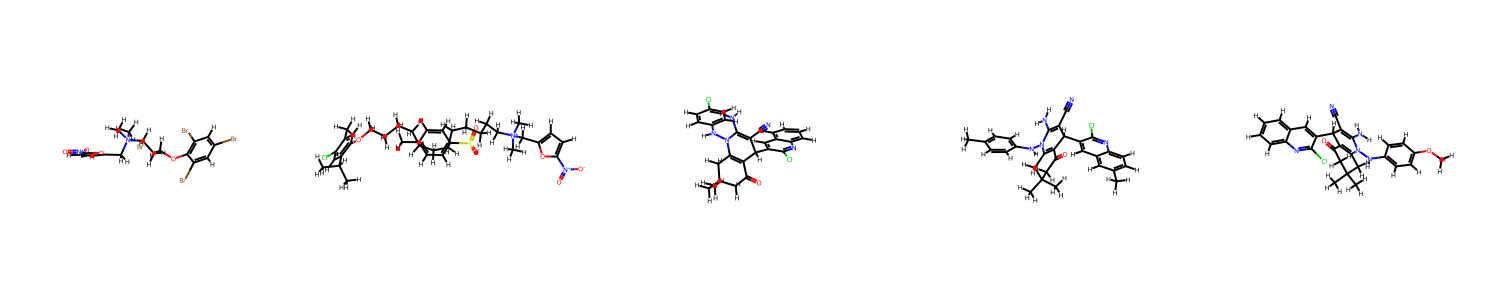

In [13]:
from rdkit.Chem import Draw

# Show first 5 molecules
Draw.MolsToGridImage(df["Processed_Molecule"].head(5), molsPerRow=5, subImgSize=(300, 300))


In [14]:
# Convert to numeric: "active" → 1, "inactive" → 0
df['Activity_Label'] = df['Activity_Label'].map({'Active': 1, 'Inactive': 0})

# Print result
print(df['Activity_Label'])

2       0
3       0
4       0
5       0
6       0
       ..
2563    1
2564    1
2565    1
2566    0
2567    0
Name: Activity_Label, Length: 1546, dtype: int64


In [15]:
df.to_csv("MIC_Dataset_Processed.csv")

In [16]:
import os
from rdkit import Chem

# Ensure output directory exists
output_folder = "mol_files"
os.makedirs(output_folder, exist_ok=True)

# Define SDF file path
sdf_filename = os.path.join(output_folder, "molecules.sdf")

# Create an SDF writer
writer = Chem.SDWriter(sdf_filename)

# Loop through DataFrame and save each molecule with properties
for idx, row in df.dropna(subset=["Processed_Molecule"]).iterrows():
    mol = row["Processed_Molecule"]
    if mol is not None:
        # Write to SDF
        writer.write(mol)

# Close writer
writer.close()

print(f"Saved {len(df.dropna(subset=['Processed_Molecule']))} molecules with activity data in SDF format!")


Saved 1546 molecules with activity data in SDF format!


In [17]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import numpy as np

# Generate fingerprints
fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in df["Processed_Molecule"]]
labels = df["Activity_Label"].values

modi_count = 0
for i, fp in enumerate(fps):
    sims = DataStructs.BulkTanimotoSimilarity(fp, fps)
    sims[i] = -1  # ignore self-similarity
    nn_idx = np.argmax(sims)  # nearest neighbor index
    if labels[i] == labels[nn_idx]:
        modi_count += 1

MODI = modi_count / len(fps)
print("MODI:", MODI)


MODI:

[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerator
[07:10:50] DEPRECATION WARNING: please use MorganGenerat

 0.8926261319534282


[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerator
[07:10:52] DEPRECATION WARNING: please use MorganGenerat

Calculated 1546 fingerprints (nBits=2048, radius=2)
Computed SALI for 8785 pairs
Pairs with SALI == 0: 405 / 8785 (4.6%)
Pairs with SALI == inf (identical sim->1 with delta>0): 2449


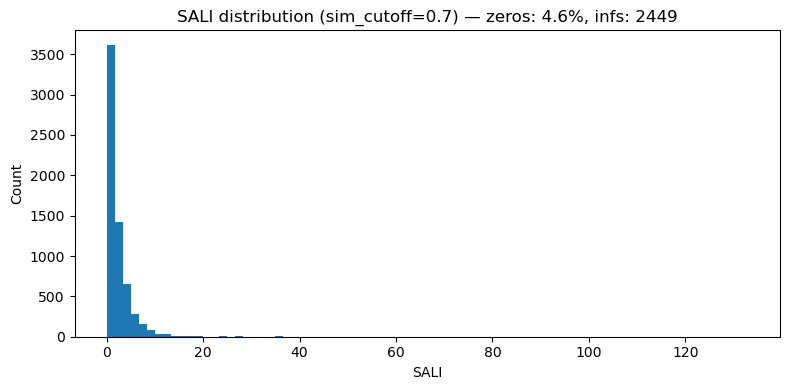

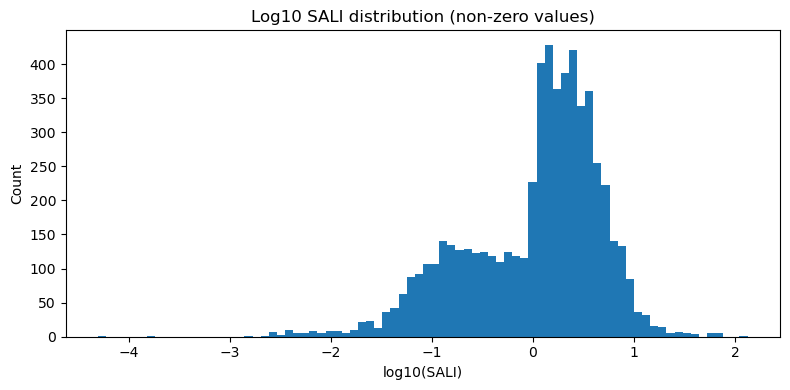


Top SALI pairs:
   i    j                                                                                   SMILES_i                                                                                 SMILES_j   pMIC_i   pMIC_j  sim  delta_pMIC          SALI
   1  347 Cc1cc(OCCCCCCCCCCCC[N+](C)(C)Cc2ccc([N+](=O)[O-])o2)c(C(C)C)cc1Cl.Cc1ccc(S(=O)(=O)[O-])cc1 Cc1cc(OCCCCCCCCCC[N+](C)(C)Cc2ccc([N+](=O)[O-])o2)c(C(C)C)cc1Cl.Cc1ccc(S(=O)(=O)[O-])cc1 3.539923 3.521981  1.0    0.017942 1.797693e+308
1541 1543                                                 O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O                                               O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O 7.043166 5.520287  1.0    1.522879 1.797693e+308
1531 1537                                                 O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O                                               O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O 6.566044 3.821317  1.0    2.744727 1.797693e+308
 397 1479                 C

In [18]:
# Dependencies: rdkit, pandas, numpy, matplotlib
# Assumes df has columns: "Processed_Molecule" (RDKit Mol) and "MIC_µM" (float).
from rdkit.Chem import AllChem, DataStructs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm  # optional, for progress (pip install tqdm)

# PARAMETERS - tweak these
nBits = 2048
radius = 2
sim_cutoff = 0.7        # only consider pairs with Tanimoto >= this
topN = 30               # number of top SALI pairs to print/save
min_pairs_to_plot = 50  # if not enough pairs pass sim_cutoff, code will fall back to pairs without cutoff

# ---- prepare activity: convert MIC(µM) to pMIC ----
# require positive MIC_µM values
df = df.dropna(subset=["MIC_µM"]).copy()
df = df[df["MIC_µM"] > 0].reset_index(drop=True)

# pMIC = -log10(MIC in M) = 6 - log10(MIC in µM)
df["pMIC"] = 6.0 - np.log10(df["MIC_µM"].astype(float))

# ---- fingerprints ----
fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nBits) for m in df["Processed_Molecule"]]
n = len(fps)
print(f"Calculated {n} fingerprints (nBits={nBits}, radius={radius})")

# ---- compute pairwise SALI but only for similar pairs ----
sali_list = []
pairs = []

# We'll compute only upper triangle i<j
for i in range(n):
    # compute similarities of i with all j>i
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[i+1:])  # length n-i-1
    for offset, sim in enumerate(sims):
        j = i + 1 + offset
        if sim <= 0: 
            continue
        # optionally filter on sim_cutoff to focus on local cliffs
        if sim < sim_cutoff:
            continue

        # activity difference (use pMIC)
        act_i = df.at[i, "pMIC"]
        act_j = df.at[j, "pMIC"]
        delta_act = abs(act_i - act_j)

        # avoid sim==1.0 (identical fingerprints) causing div by zero
        denom = 1.0 - sim
        if denom <= 1e-12:
            # treat as very large SALI (nearly identical structures with different activity)
            sali = np.inf if delta_act > 0 else 0.0
        else:
            sali = delta_act / denom

        sali_list.append(sali)
        pairs.append((i, j, sim, delta_act, sali))

# If too few pairs passed sim_cutoff, compute without cutoff (fallback)
if len(sali_list) < min_pairs_to_plot:
    print(f"Only {len(sali_list)} pairs met sim_cutoff={sim_cutoff}. Computing SALI for ALL pairs as fallback.")
    sali_list = []
    pairs = []
    for i in tqdm(range(n)):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[i+1:])
        for offset, sim in enumerate(sims):
            j = i + 1 + offset
            if sim <= 0:
                continue
            act_i = df.at[i, "pMIC"]
            act_j = df.at[j, "pMIC"]
            delta_act = abs(act_i - act_j)
            denom = 1.0 - sim
            if denom <= 1e-12:
                sali = np.inf if delta_act > 0 else 0.0
            else:
                sali = delta_act / denom
            sali_list.append(sali)
            pairs.append((i, j, sim, delta_act, sali))

sali_arr = np.array(sali_list)
print("Computed SALI for", len(sali_arr), "pairs")

# ---- diagnostics ----
n_zero = np.sum((sali_arr == 0))
pct_zero = 100.0 * n_zero / len(sali_arr) if len(sali_arr)>0 else 0.0
print(f"Pairs with SALI == 0: {n_zero} / {len(sali_arr)} ({pct_zero:.1f}%)")

# remove inf values for plotting but keep count
n_inf = np.sum(np.isinf(sali_arr))
print(f"Pairs with SALI == inf (identical sim->1 with delta>0): {n_inf}")

# create arrays excluding zeros and inf for non-zero analysis
finite_mask = np.isfinite(sali_arr)
nonzero_mask = finite_mask & (sali_arr > 0)
sali_nonzero = sali_arr[nonzero_mask]

# ---- Plot histogram (linear) ----
plt.figure(figsize=(8,4))
plt.hist(sali_arr[np.isfinite(sali_arr)], bins=80)
plt.xlabel("SALI")
plt.ylabel("Count")
plt.title(f"SALI distribution (sim_cutoff={sim_cutoff}) — zeros: {pct_zero:.1f}%, infs: {n_inf}")
plt.tight_layout()
plt.show()

# ---- Plot log histogram of non-zero SALI (more informative) ----
if len(sali_nonzero) > 0:
    plt.figure(figsize=(8,4))
    plt.hist(np.log10(sali_nonzero + 1e-12), bins=80)  # log10 of SALI
    plt.xlabel("log10(SALI)")
    plt.ylabel("Count")
    plt.title("Log10 SALI distribution (non-zero values)")
    plt.tight_layout()
    plt.show()
else:
    print("No non-zero finite SALI values to plot (after sim_cutoff filter).")

# ---- Top cliffs (largest SALI) ----
pairs_df = pd.DataFrame(pairs, columns=["i","j","sim","delta_pMIC","SALI"])
pairs_df = pairs_df.replace([np.inf, -np.inf], np.finfo(float).max)  # for sorting, optional

top = pairs_df.sort_values("SALI", ascending=False).head(topN)
print("\nTop SALI pairs:")
display_cols = []
rows = []
for _, row in top.iterrows():
    i, j = int(row["i"]), int(row["j"])
    rec = {
        "i": i,
        "j": j,
        "SMILES_i": df.at[i, "Smiles"] if "Smiles" in df.columns else None,
        "SMILES_j": df.at[j, "Smiles"] if "Smiles" in df.columns else None,
        "pMIC_i": df.at[i, "pMIC"],
        "pMIC_j": df.at[j, "pMIC"],
        "sim": row["sim"],
        "delta_pMIC": row["delta_pMIC"],
        "SALI": row["SALI"]
    }
    rows.append(rec)

top_cliffs_df = pd.DataFrame(rows)
print(top_cliffs_df.to_string(index=False))

# Save results
pairs_df.to_csv("sali_pairs_all.csv", index=False)
top_cliffs_df.to_csv("sali_top_cliffs.csv", index=False)
print("Saved sali_pairs_all.csv and sali_top_cliffs.csv")


In [19]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

X = [list(fp) for fp in fps]  # convert RDKit ExplicitBitVect to list
y = labels

knn = KNeighborsClassifier(n_neighbors=5, metric="jaccard")
knn.fit(X, y)
y_pred = knn.predict(X)

ARKA_score = accuracy_score(y, y_pred)
print("ARKA (k=5):", ARKA_score)

/opt/conda/envs/openmm-env/lib/python3.13/site-packages/sklearn/metrics/pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


ARKA (k=5): 0.9320827943078913


In [ ]:
# Padel Descriptors to calculate descriptors.

import pandas as pd
df = pd.read_csv("Descriptors.csv")
print(df.head())

In [ ]:
# Extract molecule number from name
df["mol_id"] = df["Name"].str.extract(r'AUTOGEN_molecules_(\d+)').astype(int)
print(df.head())

In [ ]:
df2 = pd.read_csv("BreastCancer_MCF7_IC50_Dataset_Processed.csv") 

# Add index as a new column 'mol_id' (starting from 1)
df2 = df2.reset_index().rename(columns={'index': 'mol_id'})
df2["mol_id"] = df2["mol_id"] + 1  # Shift index by +1

# Ensure 'mol_id' is of integer type
df2["mol_id"] = df2["mol_id"].astype(int)

print(df2.head())


In [ ]:
# Merge on 'mol_id'
merged_df = pd.merge(df, df2, on="mol_id", how="inner")

# Save the merged dataset
merged_df.to_csv("merged_dataset.csv", index=False)

# Display the result
print(merged_df.head())
# Check the column names
print("Columns in CSV:", merged_df.columns)

In [ ]:
df = merged_df

df = df.loc[:, df.nunique() > 1]  # Keeps only columns with more than 1 unique value

df = df.dropna(axis=1)  # Drops any column with NaN values

# Check the column names
print("Columns in CSV:", merged_df.columns)

In [ ]:
import re

# Columns to drop explicitly
columns_to_drop = [
    'Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase', 'Compound Key', 'Standard Type', 'Standard Relation', 'Standard Value', 'Standard Units',
    'pChEMBL Value', 'Data Validity Comment', 'Comment', 'Uo Units', 'Ligand Efficiency BEI', 'mol_id', 'Smiles', 'IC50_µM',
    'Ligand Efficiency LE', 'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate',
    'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID', 'BAO Label', 'Assay Organism',
    'Assay Tissue ChEMBL ID', 'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction',
    'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation', 'Target ChEMBL ID', 'Processed_Molecule',
    'Target Name', 'Target Organism', 'Target Type', 'Document ChEMBL ID', 'Source ID', 'Source Description', 'Name', 'Unnamed: 0',
    'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties', 'Action Type', 'Standard Text Value', 'Value', 'MIC_µM'
]

# Drop explicitly listed columns
df = df.drop(columns=columns_to_drop, errors="ignore")

# Drop columns with regex patterns
#regex_patterns = ["FP\d+", "ExtFP\d+", "GraphFP\d+", "MACCSFP\d+", "PubchemFP\d+", "SubFP\d+", 
#                  "KRFP\d+", "AD2D\d+", "SubFPC\d+", "KRFPC\d+", "APC2D\d+", "EStateFP\d+"]

# Drop columns matching the patterns
#df = df.drop(columns=[col for col in df.columns if any(re.match(pattern, col) for pattern in regex_patterns)], errors="ignore")

# Print result
print(df.head())


In [ ]:
# Save the merged dataset
df.to_csv("merged_dataset_cleaned.csv", index=False)

In [ ]:
print(df["Activity_Label"].value_counts(dropna=False))

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Total dataset size after balancing: {len(df)}")
print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")
print(train_df['Activity_Label'].value_counts())  # Check class distribution

In [ ]:
train_df.to_csv("train_dataset.csv", index=False)
test_df.to_csv("test_dataset.csv", index=False)